# From Electrochemical Data to Structured Insight

## Pt and Au Single-Crystal Cyclic Voltammetry in echemdb

This notebook investigates the distribution of cyclic voltammetry (CV)
measurements for Pt and Au single-crystal electrodes using structured
metadata extracted from echemdb.

### Research Questions

1. How are Pt and Au single-crystal CV measurements distributed across
   crystallographic orientations and electrolyte environments?

2. How do experimental conditions, particularly scan rate and
   reference-electrode usage, vary across electrode materials and
   crystallographic orientations?

The analysis combines SQLite/SQL, Pandas, and data visualization.

In [1]:
# Import libraries and connect to SQLite
from pathlib import Path
import os

print("Current working directory:")
print(Path.cwd())

print("\nContents of current directory:")
for item in Path.cwd().iterdir():
    print(item)

Current working directory:
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1

Contents of current directory:
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/EDA.ipynb
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/database
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/.DS_Store
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/Hypotheses_and_visualizations.ipynb
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/TKSarpey_ElectroCatalysisDB-EDA-and-SQL.pptx
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/Plot2.svg
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/Plot1.svg
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/EDA_and_processing.ipynb
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Wee

In [2]:
# Check whether the expected database exits
database_path = Path("../database/electrochemistry.db")

print("Expected database path:")
print(database_path.resolve())

print("\nDoes the database exist?")
print(database_path.exists())

print("\nDoes the database directory exist?")
print(database_path.parent.exists())

Expected database path:
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/database/electrochemistry.db

Does the database exist?
False

Does the database directory exist?
False


In [3]:
# Find the database
project_root = Path.cwd()

matches = list(
    project_root.parent.rglob("electrochemistry.db")
)

print("Databases found:")
for match in matches:
    print(match.resolve())

Databases found:
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/database/electrochemistry.db


In [4]:
# Fix the database connection
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project root is the current working directory
project_root = Path.cwd()

# Correct database path
database_path = project_root / "database" / "electrochemistry.db"

# Connect to SQLite
connection = sqlite3.connect(database_path)

print("Connected to:", database_path)

Connected to: /Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/database/electrochemistry.db


In [5]:
# Verify the database
print(
    "Foreign keys enabled:",
    connection.execute("PRAGMA foreign_keys;").fetchone()[0]
)

Foreign keys enabled: 0


In [6]:
# Check the tables
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    connection
)

tables

,name
0,cv_points
1,electrolytes
2,materials
3,measurements
4,orientations
5,sources
6,sqlite_sequence


In [7]:
# Turn on the foreign key
import sqlite3
from pathlib import Path

database_path = Path("database/electrochemistry.db")

connection = sqlite3.connect(database_path)

# Enable foreign-key enforcement for this connection
connection.execute("PRAGMA foreign_keys = ON;")

print(
    "Foreign keys enabled:",
    connection.execute("PRAGMA foreign_keys;").fetchone()[0]
)

Foreign keys enabled: 1


In [8]:
# Enable foreign key
fk_errors = connection.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

print("Foreign-key errors:", len(fk_errors))

Foreign-key errors: 0


In [9]:
# Check database integrity
integrity = connection.execute(
    "PRAGMA integrity_check;"
).fetchone()[0]

print("Database integrity:", integrity)

Database integrity: ok


## Hypotheses

### Hypothesis 1 — Dataset representation

Pt and Au single-crystal CV measurements are not evenly distributed
across crystallographic orientations.

Because the dataset is assembled from published literature, some
orientations may be substantially more represented than others.

### Hypothesis 2 — Experimental conditions

The reported CV measurements use a range of scan rates, and the
distribution of scan-rate categories differs between electrode
materials and orientations.

These hypotheses concern the composition of the available literature
dataset and its experimental metadata. They do not imply that one
material or crystallographic orientation has intrinsically superior
electrocatalytic activity.

In [10]:
# 
query_material_orientation = """
SELECT
    mat.material_name,
    o.orientation_name,
    COUNT(me.measurement_id) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name
ORDER BY
    mat.material_name,
    o.orientation_name;
"""

material_orientation = pd.read_sql_query(
    query_material_orientation,
    connection
)

material_orientation

,material_name,orientation_name,measurement_count
0,Au,100,8
1,Au,110,3
2,Au,111,81
3,Pt,100,11
4,Pt,110,9
5,Pt,111,95


In [11]:
# Quick check in Jupyter
from pathlib import Path
import sqlite3

database_path = Path("database/electrochemistry.db")

print("Database:", database_path.resolve())

connection = sqlite3.connect(database_path)

print(
    "Measurements:",
    connection.execute(
        "SELECT COUNT(*) FROM measurements"
    ).fetchone()[0]
)

Database: /Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/database/electrochemistry.db
Measurements: 207


In [12]:
# Keep database but reload its table
import sqlite3
import pandas as pd
from pathlib import Path

# Project 1 is the current working directory
project_root = Path.cwd()

database_path = project_root / "database" / "electrochemistry.db"
data_dir = project_root / "data" / "clean"

# Connect to the database
connection = sqlite3.connect(database_path)

# Enable foreign keys
connection.execute("PRAGMA foreign_keys = ON;")

print("Database:", database_path)
print(
    "Foreign keys enabled:",
    connection.execute("PRAGMA foreign_keys;").fetchone()[0]
)

Database: /Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/Project 1/database/electrochemistry.db
Foreign keys enabled: 1


In [13]:
# Read the six corrected CSV files
materials = pd.read_csv(data_dir / "materials.csv")
orientations = pd.read_csv(data_dir / "orientations.csv")
sources = pd.read_csv(data_dir / "sources.csv")
electrolytes = pd.read_csv(data_dir / "electrolytes.csv")
measurements = pd.read_csv(data_dir / "measurements.csv")
cv_points = pd.read_csv(data_dir / "cv_points.csv")

print("materials:", materials.shape)
print("orientations:", orientations.shape)
print("sources:", sources.shape)
print("electrolytes:", electrolytes.shape)
print("measurements:", measurements.shape)
print("cv_points:", cv_points.shape)

materials: (2, 2)
orientations: (3, 2)
sources: (53, 4)
electrolytes: (109, 9)
measurements: (207, 21)
cv_points: (704968, 8)


In [14]:
# Clear existing tables
connection.execute("PRAGMA foreign_keys = OFF;")

for table in [
    "cv_points",
    "measurements",
    "electrolytes",
    "sources",
    "orientations",
    "materials"
]:
    connection.execute(f"DELETE FROM {table}")

connection.commit()

# Turn foreign-key enforcement back on
connection.execute("PRAGMA foreign_keys = ON;")

# Load parent tables first
materials.to_sql(
    "materials",
    connection,
    if_exists="append",
    index=False
)

orientations.to_sql(
    "orientations",
    connection,
    if_exists="append",
    index=False
)

sources.to_sql(
    "sources",
    connection,
    if_exists="append",
    index=False
)

electrolytes.to_sql(
    "electrolytes",
    connection,
    if_exists="append",
    index=False
)

# Then measurements
measurements.to_sql(
    "measurements",
    connection,
    if_exists="append",
    index=False
)

# Finally CV points
cv_points.to_sql(
    "cv_points",
    connection,
    if_exists="append",
    index=False
)

connection.commit()

print("All tables loaded successfully.")

All tables loaded successfully.


In [15]:
# Close the current connection
connection.close()

In [16]:
# Delete the old database
from pathlib import Path
import sqlite3

database_path = Path("database/electrochemistry.db")

if database_path.exists():
    database_path.unlink()

print("Old database deleted.")

Old database deleted.


In [17]:
# Recreate the database using the current schema
connection = sqlite3.connect(database_path)

connection.execute("PRAGMA foreign_keys = ON;")

print(
    "Foreign keys enabled:",
    connection.execute("PRAGMA foreign_keys;").fetchone()[0]
)

Foreign keys enabled: 1


In [18]:
# Now, create the tables
schema_sql = """
PRAGMA foreign_keys = ON;

CREATE TABLE materials (
    material_id INTEGER PRIMARY KEY,
    material_name TEXT NOT NULL UNIQUE
);

CREATE TABLE orientations (
    orientation_id INTEGER PRIMARY KEY,
    orientation_name TEXT NOT NULL UNIQUE
);

CREATE TABLE sources (
    source_id INTEGER PRIMARY KEY,
    citation_key TEXT NOT NULL UNIQUE,
    doi_url TEXT,
    publication_year INTEGER
);

CREATE TABLE electrolytes (
    electrolyte_id INTEGER PRIMARY KEY,
    electrolyte_condition_key TEXT NOT NULL UNIQUE,
    electrolyte_components_canonical TEXT NOT NULL,
    electrolyte_type TEXT,
    electrolyte_condition TEXT NOT NULL,
    solvent TEXT,
    gas TEXT,
    concentrations TEXT,
    concentrations_canonical TEXT
);

CREATE TABLE measurements (
    measurement_id INTEGER PRIMARY KEY,
    entry_id TEXT NOT NULL UNIQUE,

    material_id INTEGER NOT NULL,
    orientation_id INTEGER NOT NULL,
    electrolyte_id INTEGER NOT NULL,
    source_id INTEGER NOT NULL,

    electrode_type TEXT,
    reference_electrode TEXT,
    reference_electrode_family TEXT,
    reference_electrode_detail TEXT,
    reference_material TEXT,
    counter_electrode TEXT,

    measurement_type TEXT NOT NULL,

    scan_rate_value REAL,
    scan_rate_unit TEXT,
    scan_rate_category TEXT,

    potential_name TEXT,
    potential_unit TEXT,
    potential_reference TEXT,

    current_name TEXT,
    current_unit TEXT,

    FOREIGN KEY (material_id)
        REFERENCES materials(material_id),

    FOREIGN KEY (orientation_id)
        REFERENCES orientations(orientation_id),

    FOREIGN KEY (electrolyte_id)
        REFERENCES electrolytes(electrolyte_id),

    FOREIGN KEY (source_id)
        REFERENCES sources(source_id)
);

CREATE TABLE cv_points (
    point_id INTEGER PRIMARY KEY AUTOINCREMENT,

    measurement_id INTEGER NOT NULL,
    entry_id TEXT NOT NULL,

    t REAL NOT NULL,
    E REAL NOT NULL,

    j REAL,
    I REAL,
    cycle INTEGER,

    signal_type TEXT NOT NULL,

    FOREIGN KEY (measurement_id)
        REFERENCES measurements(measurement_id),

    FOREIGN KEY (entry_id)
        REFERENCES measurements(entry_id)
);
"""

connection.executescript(schema_sql)
connection.commit()

print("Database schema created successfully.")

Database schema created successfully.


In [19]:
# Check the new electrolytes structure
print(
    pd.read_csv(data_dir / "electrolytes.csv").columns.tolist()
)

['electrolyte_id', 'electrolyte_condition_key', 'electrolyte_components_canonical', 'electrolyte_type', 'electrolyte_condition', 'solvent', 'gas', 'concentrations', 'concentrations_canonical']


In [20]:
# Check the actual SQLite table
columns = connection.execute(
    "PRAGMA table_info(electrolytes);"
).fetchall()

for column in columns:
    print(column[1])

electrolyte_id
electrolyte_condition_key
electrolyte_components_canonical
electrolyte_type
electrolyte_condition
solvent
gas
concentrations
concentrations_canonical


In [21]:
# Load the CSVs
materials.to_sql(
    "materials",
    connection,
    if_exists="append",
    index=False
)

orientations.to_sql(
    "orientations",
    connection,
    if_exists="append",
    index=False
)

sources.to_sql(
    "sources",
    connection,
    if_exists="append",
    index=False
)

electrolytes.to_sql(
    "electrolytes",
    connection,
    if_exists="append",
    index=False
)

measurements.to_sql(
    "measurements",
    connection,
    if_exists="append",
    index=False
)

cv_points.to_sql(
    "cv_points",
    connection,
    if_exists="append",
    index=False
)

connection.commit()

print("All six tables loaded successfully.")

All six tables loaded successfully.


In [22]:
# Validate the database
tables = [
    "materials",
    "orientations",
    "sources",
    "electrolytes",
    "measurements",
    "cv_points"
]

for table in tables:
    count = connection.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]

    print(f"{table:15s}: {count:,}")

materials      : 2
orientations   : 3
sources        : 53
electrolytes   : 109
measurements   : 207
cv_points      : 704,968


In [23]:
# Check the foreign key for errors and the database integrity
fk_errors = connection.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

print("Foreign-key errors:", len(fk_errors))

integrity = connection.execute(
    "PRAGMA integrity_check;"
).fetchone()[0]

print("Database integrity:", integrity)

Foreign-key errors: 0
Database integrity: ok


In [24]:
# Check the foreign key for errors
fk_errors = connection.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

print("Foreign-key errors:", len(fk_errors))

Foreign-key errors: 0


In [25]:
# Check the database integrity
integrity = connection.execute(
    "PRAGMA integrity_check;"
).fetchone()[0]

print("Database integrity:", integrity)

Database integrity: ok


In [26]:
# Test research question 1
query_material_orientation = """
SELECT
    mat.material_name,
    o.orientation_name,
    COUNT(me.measurement_id) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name
ORDER BY
    mat.material_name,
    o.orientation_name;
"""

material_orientation = pd.read_sql_query(
    query_material_orientation,
    connection
)

material_orientation

,material_name,orientation_name,measurement_count
0,Au,100,8
1,Au,110,3
2,Au,111,81
3,Pt,100,11
4,Pt,110,9
5,Pt,111,95


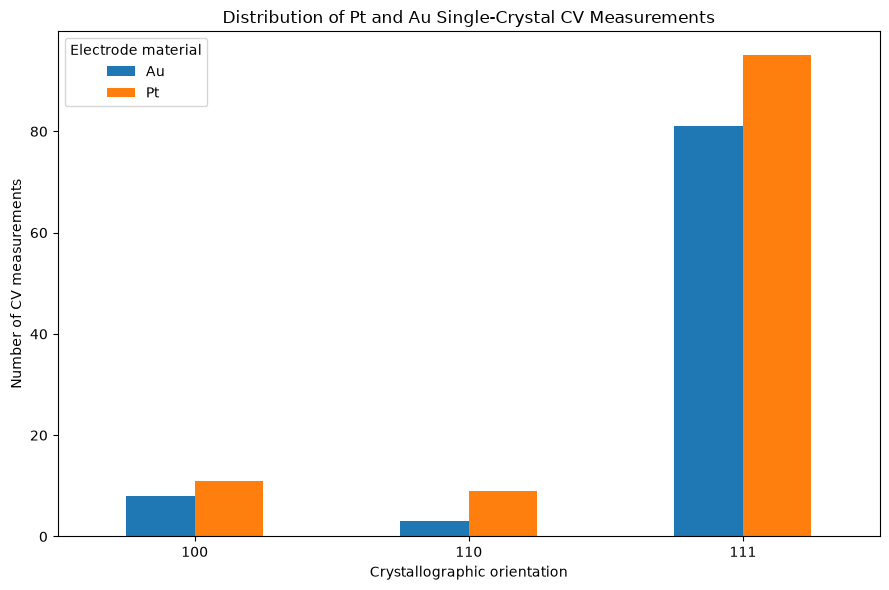

In [27]:
# Visualize research question 1
plot_data = material_orientation.pivot(
    index="orientation_name",
    columns="material_name",
    values="measurement_count"
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 6)
)

ax.set_xlabel("Crystallographic orientation")
ax.set_ylabel("Number of CV measurements")
ax.set_title(
    "Distribution of Pt and Au Single-Crystal CV Measurements"
)

plt.xticks(rotation=0)
plt.legend(title="Electrode material")
plt.tight_layout()
plt.show()

In [28]:
# Calculate the totals by orientation
orientation_totals = (
    material_orientation
    .groupby("orientation_name")["measurement_count"]
    .sum()
    .sort_values(ascending=False)
)

orientation_totals

orientation_name
111    176
100     19
110     12
Name: measurement_count, dtype: int64

In [29]:
# Calculate the percentage distribution
orientation_percentages = (
    orientation_totals / orientation_totals.sum() * 100
).round(1)

orientation_percentages

orientation_name
111    85.0
100     9.2
110     5.8
Name: measurement_count, dtype: float64

## Research Question 1 — Material and Crystallographic Orientation

**Research question:**  
How are Pt and Au single-crystal cyclic voltammetry measurements distributed across crystallographic orientations?

**Hypothesis:**  
The measurements are not evenly distributed across the three crystallographic orientations (100, 110, and 111).

Because this dataset is derived from published literature, the number of records represents the distribution of measurements available in echemdb rather than the intrinsic electrochemical importance or activity of a particular surface orientation.

In [30]:
# Test research question 1
query_material_orientation = """
SELECT
    mat.material_name,
    o.orientation_name,
    COUNT(me.measurement_id) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name
ORDER BY
    mat.material_name,
    o.orientation_name;
"""

material_orientation = pd.read_sql_query(
    query_material_orientation,
    connection
)

material_orientation

,material_name,orientation_name,measurement_count
0,Au,100,8
1,Au,110,3
2,Au,111,81
3,Pt,100,11
4,Pt,110,9
5,Pt,111,95


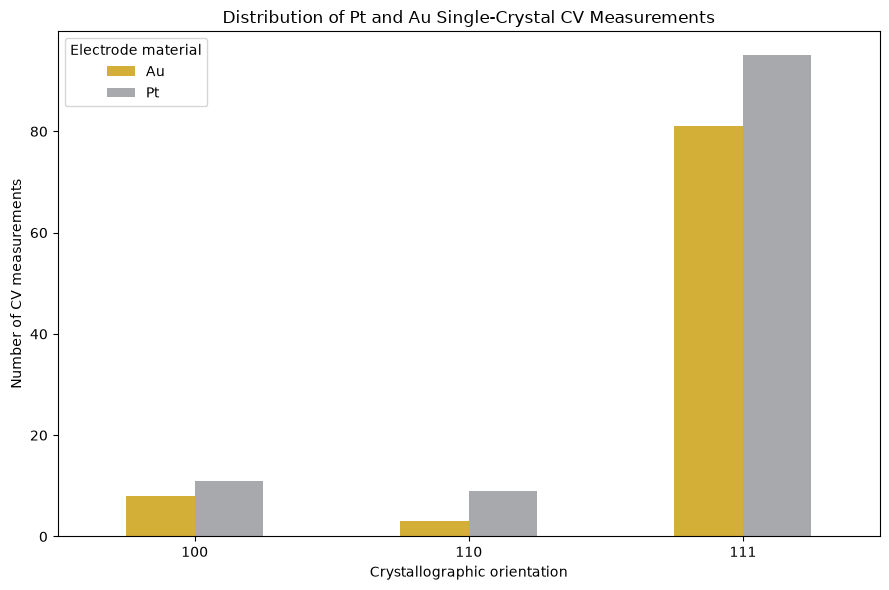

In [31]:
# Visualize research question one
plot_data = material_orientation.pivot(
    index="orientation_name",
    columns="material_name",
    values="measurement_count"
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 6),
    color={
        "Au": "#D4AF37",   # Gold
        "Pt": "#A7A9AC"    # Platinum / metallic gray
    }
)

ax.set_xlabel("Crystallographic orientation")
ax.set_ylabel("Number of CV measurements")

ax.set_title(
    "Distribution of Pt and Au Single-Crystal CV Measurements"
)

plt.xticks(rotation=0)
plt.legend(title="Electrode material")
plt.tight_layout()
plt.show()

In [32]:
# Calculate the totals by orientation
orientation_totals = (
    material_orientation
    .groupby("orientation_name")["measurement_count"]
    .sum()
    .sort_values(ascending=False)
)

orientation_totals

orientation_name
111    176
100     19
110     12
Name: measurement_count, dtype: int64

In [33]:
# Calculate the percentage distribution
orientation_percentages = (
    orientation_totals
    / orientation_totals.sum()
    * 100
).round(1)

orientation_percentages

orientation_name
111    85.0
100     9.2
110     5.8
Name: measurement_count, dtype: float64

In [34]:
# Statistical Summary of orientation
orientation_summary = pd.DataFrame({
    "measurement_count": orientation_totals,
    "percentage": orientation_percentages
})

orientation_summary

,measurement_count,percentage
orientation_name,,
111,176,85.0
100,19,9.2
110,12,5.8


In [35]:
# Compare Pt and Au separately
material_totals = (
    material_orientation
    .groupby("material_name")["measurement_count"]
    .sum()
)

material_totals

material_name
Au     92
Pt    115
Name: measurement_count, dtype: int64

In [36]:
# Calculate the percentages within each material
material_orientation["material_percentage"] = (
    material_orientation
    .groupby("material_name")["measurement_count"]
    .transform(
        lambda x: x / x.sum() * 100
    )
).round(1)

material_orientation

,material_name,orientation_name,measurement_count,material_percentage
0,Au,100,8,8.7
1,Au,110,3,3.3
2,Au,111,81,88.0
3,Pt,100,11,9.6
4,Pt,110,9,7.8
5,Pt,111,95,82.6


### Interpretation

The 207 CV measurements are distributed unevenly across the three crystallographic orientations and between the two electrode materials, Pt and Au.

The results indicate that some crystallographic orientations are substantially more represented in the echemdb records than others. The distribution also differs between Pt and Au, showing that the literature coverage is not uniform across material–orientation combinations.

This finding supports the descriptive hypothesis that the dataset does not contain an even representation of all crystallographic orientations.

Importantly, the measurement count should not be interpreted as a measure of intrinsic electrochemical activity or scientific importance. The counts reflect the measurements represented in the echemdb literature dataset and may be influenced by publication history, research interests, experimental feasibility, and data availability.

## Research Question 2 — Scan Rate and Experimental Conditions

**Research question:**  
How do reported scan rates vary across Pt and Au single-crystal electrodes and their crystallographic orientations?

**Hypothesis:**  
The CV measurements cover a range of scan rates, and the distribution of scan-rate categories differs across material–orientation combinations.

Scan rate is treated here as an experimental-condition variable rather than as a direct indicator of electrochemical performance.

In [37]:
# SQL query for scan-rate categories
query_scan_statistics = """
SELECT
    mat.material_name,
    o.orientation_name,
    COUNT(*) AS measurement_count,
    ROUND(AVG(me.scan_rate_value), 2) AS mean_scan_rate,
    MIN(me.scan_rate_value) AS minimum_scan_rate,
    MAX(me.scan_rate_value) AS maximum_scan_rate
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name
ORDER BY
    mat.material_name,
    o.orientation_name;
"""

scan_statistics = pd.read_sql_query(
    query_scan_statistics,
    connection
)

scan_statistics

,material_name,orientation_name,measurement_count,mean_scan_rate,minimum_scan_rate,maximum_scan_rate
0,Au,100,8,10.00,10.0,10.0
1,Au,110,3,15.00,5.0,20.0
2,Au,111,81,27.53,5.0,100.0
3,Pt,100,11,50.00,50.0,50.0
4,Pt,110,9,45.56,10.0,50.0
5,Pt,111,95,48.74,10.0,100.0


In [38]:
# Look at the actual scan-ratre statistics
query_scan_rate = """
SELECT
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category,
    COUNT(*) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category
ORDER BY
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category;
"""

scan_rate_data = pd.read_sql_query(
    query_scan_rate,
    connection
)

scan_rate_data

,material_name,orientation_name,scan_rate_category,measurement_count
0,Au,100,Low,8
1,Au,110,Low,1
2,Au,110,Medium,2
3,Au,111,High,9
4,Au,111,Low,54
5,Au,111,Medium,18
6,Pt,100,Medium,11
7,Pt,110,Low,1
8,Pt,110,Medium,8
9,Pt,111,High,2


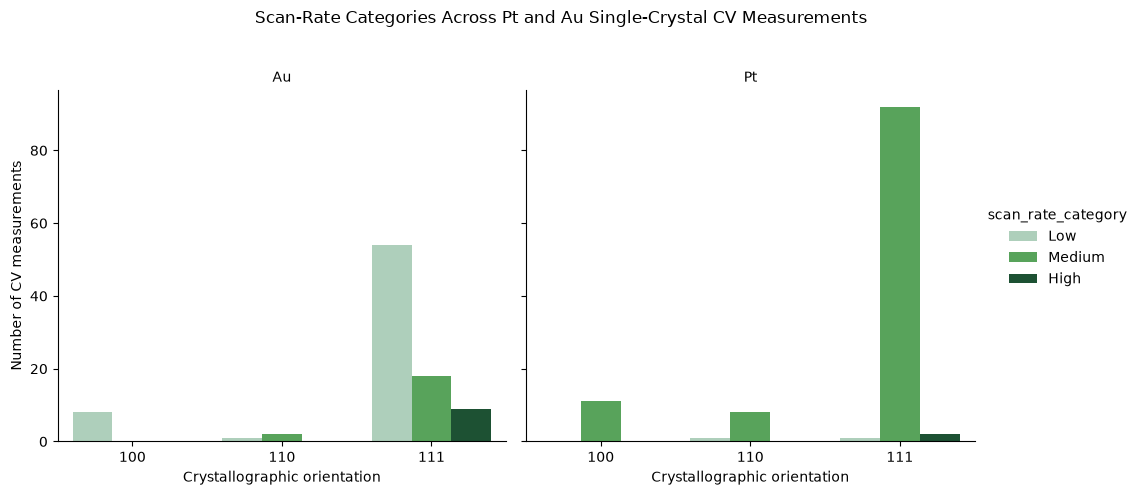

In [39]:
# Visualize the second research question
g = sns.catplot(
    data=scan_rate_data,
    x="orientation_name",
    y="measurement_count",
    hue="scan_rate_category",
    col="material_name",
    kind="bar",
    errorbar=None,
    height=5,
    aspect=1.0,
    palette={
        "Low": "#A8D5BA",
        "Medium": "#4CAF50",
        "High": "#145A32"
    }
)

g.set_axis_labels(
    "Crystallographic orientation",
    "Number of CV measurements"
)

g.set_titles("{col_name}")

g.figure.subplots_adjust(top=0.82)

g.figure.suptitle(
    "Scan-Rate Categories Across Pt and Au Single-Crystal CV Measurements"
)

plt.show()

In [40]:
# Add a data-quality check
query_current_units = """
SELECT
    current_unit,
    COUNT(*) AS measurement_count
FROM measurements
GROUP BY current_unit
ORDER BY measurement_count DESC;
"""

current_units = pd.read_sql_query(
    query_current_units,
    connection
)

current_units

,current_unit,measurement_count
0,uA / cm2,161
1,mA / cm2,14
2,µA cm⁻²,13
3,uA,8
4,V,6
5,mA,3
6,uA cm-2,1
7,nA / cm2,1


### Data-quality consideration

The current-related metadata are heterogeneous across the literature records. Some measurements report current density, while others report absolute current, and the units are not uniform.

Therefore, raw current values are not directly comparable across all records without additional unit and metadata normalization.

For this project, the analysis therefore focuses on measurement metadata and experimental conditions such as electrode material, crystallographic orientation, electrolyte environment, and scan rate rather than making direct quantitative comparisons of electrochemical current.

## 5. Conclusions

This project transformed electrochemical cyclic voltammetry data from echemdb into a structured relational SQLite database and used SQL and Python to investigate patterns in Pt and Au single-crystal measurements.

### Research Question 1 — Material and crystallographic orientation

The 207 selected CV measurements are not evenly distributed across Pt and Au or across the three crystallographic orientations (100, 110, and 111). Some material–orientation combinations are substantially more represented than others.

This supports the descriptive hypothesis that the literature records are unevenly distributed across crystallographic orientations.

However, measurement frequency should not be interpreted as a measure of intrinsic electrochemical activity or scientific importance. The distribution reflects the literature represented in echemdb and may be affected by publication history, research interests, experimental availability, and data availability.

### Research Question 2 — Scan rate and experimental conditions

The measurements cover a range of CV scan rates, and the distribution of scan-rate categories varies across electrode materials and crystallographic orientations.

This supports the hypothesis that the experimental conditions represented in the database are not uniform.

Scan rate is treated as an experimental-condition variable rather than as a direct measure of electrochemical performance.

### Data-quality considerations

The database contains heterogeneous current metadata. Some measurements report current density while others report absolute current, and several different units are represented.

Consequently, raw current values cannot be directly compared across all records without additional normalization and validation.

The analysis therefore focuses on robust metadata-level comparisons rather than making unsupported quantitative claims about intrinsic electrochemical activity.

### Overall conclusion

The project demonstrates how a scientific dataset can be transformed into a normalized relational database and subsequently analyzed using SQL and Python.

The resulting workflow connects:

Raw echemdb data → Python extraction → data cleaning → normalized CSV tables → SQLite database → SQL analysis → Python visualization → scientific interpretation.

The project also demonstrates the importance of data-quality checks when combining measurements originating from different experimental studies.

In [41]:
# Final database validation

tables = [
    "materials",
    "orientations",
    "sources",
    "electrolytes",
    "measurements",
    "cv_points"
]

print("FINAL DATABASE VALIDATION")
print("-" * 40)

for table in tables:
    count = connection.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]
    print(f"{table:15s}: {count:,}")

fk_errors = connection.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

integrity = connection.execute(
    "PRAGMA integrity_check;"
).fetchone()[0]

print("-" * 40)
print("Foreign-key errors:", len(fk_errors))
print("Database integrity:", integrity)

FINAL DATABASE VALIDATION
----------------------------------------
materials      : 2
orientations   : 3
sources        : 53
electrolytes   : 109
measurements   : 207
cv_points      : 704,968
----------------------------------------
Foreign-key errors: 0
Database integrity: ok


In [42]:
connection.close()

print("SQLite connection closed.")

SQLite connection closed.
